# 🐟 Fish Quality Grading - Multi-Stage Training Pipeline with Visualizations

This notebook trains three deep learning models with real-time progress tracking and comprehensive result visualizations:
1. **Stage 1**: Binary Classification (Fish vs Non-fish)
2. **Stage 2**: Species Classification (6 species)
3. **Stage 3**: Grade Classification (A, B, C)

Models are trained and converted to ONNX format for mobile deployment.

---

## 1️⃣ Install Required Packages

In [1]:
# Install required packages
import subprocess
import sys

packages = [
    'torch',
    'torchvision',
    'timm',
    'numpy',
    'pandas',
    'scikit-learn',
    'Pillow',
    'onnx',
    'onnxruntime',
    'matplotlib',
    'seaborn'
]

for package in packages:
    print(f'Installing {package}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('✅ All packages installed successfully!')

Installing torch...
Installing torchvision...
Installing timm...
Installing numpy...
Installing pandas...
Installing scikit-learn...
Installing Pillow...
Installing onnx...
Installing onnxruntime...
Installing matplotlib...
Installing seaborn...
✅ All packages installed successfully!


## 2️⃣ Import Libraries

In [2]:
import os
import copy
import random
import warnings
from collections import Counter
from pathlib import Path
import json

import numpy as np
import pandas as pd
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, clear_output

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import autocast, GradScaler

import timm
import onnx
import onnxruntime as ort

warnings.filterwarnings("ignore")

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ All libraries imported successfully!')

c:\Users\User\Desktop\Research Final Year\Test RP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!


## 3️⃣ Configuration & File Setup

In [3]:
# =========================================================
# CONFIGURATION - SET YOUR DATA DIRECTORY HERE
# =========================================================

from pathlib import Path

# UPDATE THIS TO YOUR CSV DIRECTORY
DATA_DIR = Path(r"C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv")

# Verify directory exists
if not DATA_DIR.exists():
    print(f"❌ Directory not found: {DATA_DIR}")
    print("Please update DATA_DIR with your correct path")
else:
    os.chdir(str(DATA_DIR))
    print(f"✅ Working directory: {os.getcwd()}")

# CSV paths
STAGE1_TRAIN_CSV = "stage1_train.csv"
STAGE2_TRAIN_CSV = "stage2_species_train.csv"
STAGE3_TRAIN_CSV = "stage3_grade_train.csv"

# Verify CSV files
print("\n📁 Checking CSV files:")
for csv_file in [STAGE1_TRAIN_CSV, STAGE2_TRAIN_CSV, STAGE3_TRAIN_CSV]:
    csv_path = DATA_DIR / csv_file
    status = "✅" if csv_path.exists() else "❌"
    print(f"  {status} {csv_file}")

# Model paths (save to train subdirectory)
train_dir = DATA_DIR / "train"
train_dir.mkdir(parents=True, exist_ok=True)

STAGE1_MODEL_PATH = str(train_dir / "Effecient_best1_binary_model.pth")
STAGE2_MODEL_PATH = str(train_dir / "Effecient_best1_species_model.pth")
STAGE3_MODEL_PATH = str(train_dir / "Effecient_best1_grade_model.pth")

# ONNX model paths
STAGE1_ONNX_PATH = str(train_dir / "Effecient_best1_binary_model.onnx")
STAGE2_ONNX_PATH = str(train_dir / "Effecient_best1_species_model.onnx")
STAGE3_ONNX_PATH = str(train_dir / "Effecient_best1_grade_model.onnx")

# Training parameters
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LR = 2e-4
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BACKBONE = "efficientnet_b0"
DROPOUT_RATE = 0.3
FREEZE_EPOCHS = 3
UNFREEZE_LR = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
PATIENCE = 15
VAL_SIZE = 0.15
TEST_SIZE = 0.15
SEED = 42

# Set seed for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"\n⚙️ Training Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Backbone: {BACKBONE}")

✅ Working directory: C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv

📁 Checking CSV files:
  ✅ stage1_train.csv
  ✅ stage2_species_train.csv
  ✅ stage3_grade_train.csv

⚙️ Training Configuration:
  Device: cpu
  Batch size: 16
  Epochs: 50
  Backbone: efficientnet_b0


In [4]:
# =========================================================
# DIAGNOSTIC: Check current working directory and path
# =========================================================
print("🔍 DIAGNOSTIC INFO:")
print(f"Current working directory: {os.getcwd()}")
print(f"Script location (if available): {os.path.abspath('.')}")

# Test different path approaches
test_path = r"C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv"
print(f"\nTesting path: {test_path}")
print(f"Path exists (raw string): {os.path.exists(test_path)}")

# Alternative: Use Path object from pathlib
from pathlib import Path
test_path_obj = Path(test_path)
print(f"Path exists (pathlib): {test_path_obj.exists()}")

# List contents if path exists
if test_path_obj.exists():
    print(f"\n✅ Path found! Contents:")
    for item in test_path_obj.glob("*.csv"):
        print(f"  - {item.name}")

🔍 DIAGNOSTIC INFO:
Current working directory: C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv
Script location (if available): C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv

Testing path: C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv
Path exists (raw string): True
Path exists (pathlib): True

✅ Path found! Contents:
  - stage1_test.csv
  - stage1_train.csv
  - stage1_val.csv
  - stage2_species_test.csv
  - stage2_species_train.csv
  - stage2_species_val.csv
  - stage3_grade_test.csv
  - stage3_grade_train.csv
  - stage3_grade_val.csv


## 4️⃣ Dataset Class

In [5]:
class FishDataset(Dataset):
    def __init__(self, dataframe, label_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.label_column = label_column
        self.transform = transform
        
        # Create label mapping
        self.unique_labels = sorted(self.df[label_column].unique())
        self.label_to_idx = {label: idx for idx, label in enumerate(self.unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}
        
    def __len__(self):
        return len(self.df)
    
    def _load_image(self, path):
        try:
            if not os.path.exists(path):
                return Image.new("RGB", (IMG_SIZE, IMG_SIZE), color="black")
            return Image.open(path).convert("RGB")
        except Exception as e:
            return Image.new("RGB", (IMG_SIZE, IMG_SIZE), color="black")
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        left_img = self._load_image(row["left_image"])
        right_img = self._load_image(row["right_image"])
        
        if self.transform:
            left_img = self.transform(left_img)
            right_img = self.transform(right_img)
        
        label = self.label_to_idx[row[self.label_column]]
        
        return left_img, right_img, torch.tensor(label, dtype=torch.long)

print('✅ FishDataset class defined')

✅ FishDataset class defined


## 5️⃣ Model Architecture

In [6]:
class DualViewClassifier(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", num_classes=2, dropout_rate=0.3):
        super().__init__()
        
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feat_dim = self.backbone(dummy).shape[1]
        
        self.feat_dim = feat_dim
        
        self.attention = nn.Sequential(
            nn.Linear(feat_dim * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 2),
            nn.Softmax(dim=1)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.8),
            
            nn.Linear(256, num_classes)
        )
        
        self.aux_left = nn.Linear(feat_dim, num_classes)
        self.aux_right = nn.Linear(feat_dim, num_classes)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, left, right, return_aux=False):
        f_left = self.backbone(left)
        f_right = self.backbone(right)
        
        fused = torch.cat([f_left, f_right], dim=1)
        
        weights = self.attention(fused)
        w_left = weights[:, 0].unsqueeze(1)
        w_right = weights[:, 1].unsqueeze(1)
        
        weighted_left = f_left * w_left
        weighted_right = f_right * w_right
        
        fused_weighted = torch.cat([weighted_left, weighted_right], dim=1)
        logits = self.classifier(fused_weighted)
        
        if return_aux:
            aux_left = self.aux_left(f_left)
            aux_right = self.aux_right(f_right)
            return logits, aux_left, aux_right
        
        return logits

print('✅ DualViewClassifier model defined')

✅ DualViewClassifier model defined


## 6️⃣ Training Functions

In [7]:
def create_train_val_test_splits(csv_path, label_column):
    """Create train/val/test splits from CSV"""
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=[label_column, "left_image", "right_image"]).reset_index(drop=True)
    
    train_df, temp_df = train_test_split(
        df, 
        test_size=(VAL_SIZE + TEST_SIZE),
        stratify=df[label_column],
        random_state=SEED
    )
    
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_SIZE/(VAL_SIZE + TEST_SIZE),
        stratify=temp_df[label_column],
        random_state=SEED
    )
    
    return train_df, val_df, test_df


def get_weighted_sampler(dataset):
    """Create weighted sampler for imbalanced data"""
    labels = [dataset.label_to_idx[dataset.df.iloc[i][dataset.label_column]] 
              for i in range(len(dataset))]
    
    class_counts = Counter(labels)
    weights = [1.0 / class_counts[label] for label in labels]
    
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


def train_epoch(model, loader, optimizer, criterion, scaler):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for left, right, labels in loader:
        left = left.to(DEVICE)
        right = right.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast(enabled=(DEVICE == "cuda")):
            logits, aux_left, aux_right = model(left, right, return_aux=True)
            
            main_loss = criterion(logits, labels)
            aux_loss_left = criterion(aux_left, labels)
            aux_loss_right = criterion(aux_right, labels)
            
            loss = main_loss + 0.3 * aux_loss_left + 0.3 * aux_loss_right
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


def validate_epoch(model, loader, criterion):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for left, right, labels in loader:
            left = left.to(DEVICE)
            right = right.to(DEVICE)
            labels = labels.to(DEVICE)
            
            with autocast(enabled=(DEVICE == "cuda")):
                logits = model(left, right)
                loss = criterion(logits, labels)
            
            preds = logits.argmax(dim=1)
            
            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = total_correct / total_samples
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return total_loss / total_samples, accuracy, balanced_acc, macro_f1, all_preds, all_labels

print('✅ Training functions defined')

✅ Training functions defined


## 7️⃣ Visualization Functions

In [8]:
def plot_training_history(train_losses, val_losses, train_accs, val_bal_accs, stage_name):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=3, linewidth=2)
    axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=3, linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{stage_name} - Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(train_accs, label='Train Accuracy', marker='o', markersize=3, linewidth=2)
    axes[1].plot(val_bal_accs, label='Val Balanced Accuracy', marker='s', markersize=3, linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{stage_name} - Training Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, stage_name):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 12}
    )
    plt.title(f'{stage_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_class_distribution(df, label_column, stage_name):
    """Plot class distribution"""
    class_counts = df[label_column].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
    bars = ax.bar(range(len(class_counts)), class_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_xticks(range(len(class_counts)))
    ax.set_xticklabels(class_counts.index, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(f'{stage_name} - Class Distribution', fontsize=14, fontweight='bold')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def plot_results_summary(test_acc, test_bal_acc, test_f1, stage_name):
    """Plot test results summary"""
    metrics = ['Accuracy', 'Balanced Accuracy', 'F1 Score']
    values = [test_acc, test_bal_acc, test_f1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars = ax.barh(metrics, values, color=colors, edgecolor='black', linewidth=2)
    
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{stage_name} - Test Results', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + 0.02, i, f'{val:.4f}', va='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print('✅ Visualization functions defined')

✅ Visualization functions defined


## 8️⃣ ONNX Conversion & Verification

In [9]:
def convert_to_onnx(pytorch_model, onnx_path, num_classes):
    """Convert PyTorch model to ONNX format"""
    print(f"\n🔄 Converting model to ONNX: {onnx_path}")
    
    pytorch_model.eval()
    
    # Create dummy inputs
    dummy_left = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_right = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    
    # Export to ONNX
    torch.onnx.export(
        pytorch_model,
        (dummy_left, dummy_right),
        onnx_path,
        input_names=['left_image', 'right_image'],
        output_names=['logits'],
        dynamic_axes={
            'left_image': {0: 'batch_size'},
            'right_image': {0: 'batch_size'},
            'logits': {0: 'batch_size'}
        },
        opset_version=14,
        do_constant_folding=True,
        verbose=False
    )
    
    # Verify the ONNX model
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    
    print(f"✅ ONNX model saved successfully")
    print(f"✅ ONNX model verified successfully")
    
    # Test inference with ONNX Runtime
    try:
        sess = ort.InferenceSession(onnx_path)
        test_input_left = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
        test_input_right = np.random.randn(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
        
        outputs = sess.run(
            None,
            {'left_image': test_input_left, 'right_image': test_input_right}
        )
        print(f"✅ ONNX inference test passed. Output shape: {outputs[0].shape}")
    except Exception as e:
        print(f"⚠️ Warning during ONNX inference test: {e}")

print('✅ ONNX conversion function defined')

✅ ONNX conversion function defined


## 9️⃣ Main Training Function with Logging

In [10]:
def train_stage(csv_path, label_column, model_save_path, onnx_save_path, stage_name):
    """Train a single stage with visualization"""
    print(f"\n{'='*80}")
    print(f"🚀 TRAINING STAGE {stage_name}")
    print(f"{'='*80}")
    
    # Check if CSV exists
    if not os.path.exists(csv_path):
        print(f"❌ CSV file not found: {csv_path}")
        return None, {}, {}
    
    # Create splits
    train_df, val_df, test_df = create_train_val_test_splits(csv_path, label_column)
    
    # Plot class distribution
    print(f"\n📊 Data Distribution:")
    plot_class_distribution(train_df, label_column, f"{stage_name} - Training Data")
    
    # Transforms
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Datasets
    train_dataset = FishDataset(train_df, label_column, transform=train_transform)
    val_dataset = FishDataset(val_df, label_column, transform=val_transform)
    test_dataset = FishDataset(test_df, label_column, transform=val_transform)
    
    num_classes = len(train_dataset.unique_labels)
    
    print(f"\n📈 Dataset Info:")
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Val samples: {len(val_dataset)}")
    print(f"  Test samples: {len(test_dataset)}")
    print(f"  Classes: {train_dataset.unique_labels}")
    
    # DataLoaders
    sampler = get_weighted_sampler(train_dataset)
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"), drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda")
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda")
    )
    
    # Model
    model = DualViewClassifier(
        backbone_name=BACKBONE,
        num_classes=num_classes,
        dropout_rate=DROPOUT_RATE
    ).to(DEVICE)
    
    # Freeze backbone initially
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    # Loss with class weights
    labels = [train_dataset.label_to_idx[train_df.iloc[i][label_column]] 
              for i in range(len(train_df))]
    class_counts = Counter(labels)
    class_weights = torch.tensor([
        len(labels) / (num_classes * class_counts.get(i, 1)) 
        for i in range(num_classes)
    ], dtype=torch.float32).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    
    # Optimizer
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    scaler = GradScaler(enabled=(DEVICE == "cuda"))
    
    # Training loop with history tracking
    train_losses, val_losses = [], []
    train_accs, val_bal_accs = [], []
    best_val_balanced_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    
    print(f"\n⏳ Starting training...")
    
    for epoch in range(1, EPOCHS + 1):
        # Unfreeze backbone
        if epoch == FREEZE_EPOCHS + 1:
            for param in model.backbone.parameters():
                param.requires_grad = True
            
            optimizer = AdamW(model.parameters(), lr=UNFREEZE_LR, weight_decay=WEIGHT_DECAY)
            scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
            print(f"\n🔓 Backbone unfrozen at epoch {epoch}")
        
        # Train and validate
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = validate_epoch(model, val_loader, criterion)
        
        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_bal_accs.append(val_bal_acc)
        
        scheduler.step(val_bal_acc)
        
        # Print progress
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {train_loss:.4f}/{val_loss:.4f} | "
                  f"Acc: {train_acc:.4f}/{val_bal_acc:.4f}")
        
        # Save best model
        if val_bal_acc > best_val_balanced_acc:
            best_val_balanced_acc = val_bal_acc
            best_epoch = epoch
            torch.save(model.state_dict(), model_save_path)
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch}")
            break
    
    print(f"\n✨ Best model from epoch {best_epoch} (Bal Acc: {best_val_balanced_acc:.4f})")
    
    # Plot training history
    print(f"\n📉 Training History:")
    plot_training_history(train_losses, val_losses, train_accs, val_bal_accs, stage_name)
    
    # Test evaluation
    model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))
    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion
    )
    
    print(f"\n🎯 Test Results:")
    plot_results_summary(test_acc, test_bal_acc, test_f1, stage_name)
    
    # Confusion matrix
    print(f"\n🗂️ Confusion Matrix:")
    target_names = [train_dataset.idx_to_label[i] for i in range(num_classes)]
    plot_confusion_matrix(test_labels, test_preds, target_names, stage_name)
    
    # Classification report
    print(f"\n📋 Classification Report:")
    report = classification_report(test_labels, test_preds, target_names=target_names, digits=4)
    print(report)
    
    # Convert to ONNX
    print(f"\n🔄 ONNX Conversion:")
    convert_to_onnx(model, onnx_save_path, num_classes)
    
    return model, train_dataset.label_to_idx, train_dataset.idx_to_label

print('✅ Main training function defined')

✅ Main training function defined


## 🔟 STAGE 1: Binary Classification (Fish vs Non-fish)


🚀 TRAINING STAGE 1 - BINARY CLASSIFICATION

📊 Data Distribution:


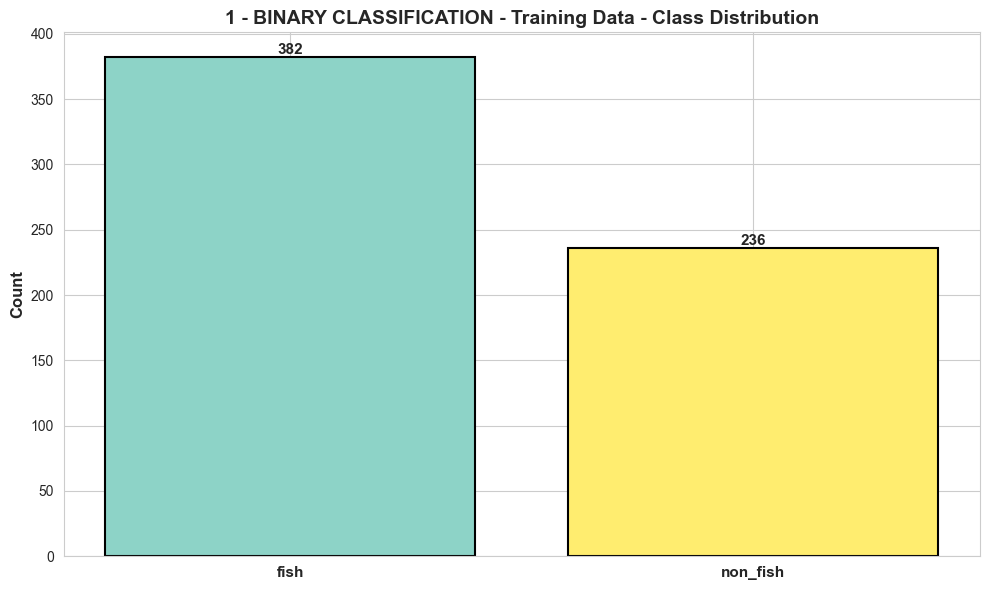


📈 Dataset Info:
  Train samples: 618
  Val samples: 133
  Test samples: 133
  Classes: ['fish', 'non_fish']

⏳ Starting training...
Epoch 01/50 | Loss: 0.7487/0.2669 | Acc: 0.8618/0.9817

🔓 Backbone unfrozen at epoch 4
Epoch 05/50 | Loss: 0.3863/0.2458 | Acc: 0.9951/1.0000
Epoch 10/50 | Loss: 0.3557/0.2285 | Acc: 0.9984/1.0000
Epoch 15/50 | Loss: 0.3626/0.2239 | Acc: 0.9967/1.0000

⏹️ Early stopping at epoch 19

✨ Best model from epoch 4 (Bal Acc: 1.0000)

📉 Training History:


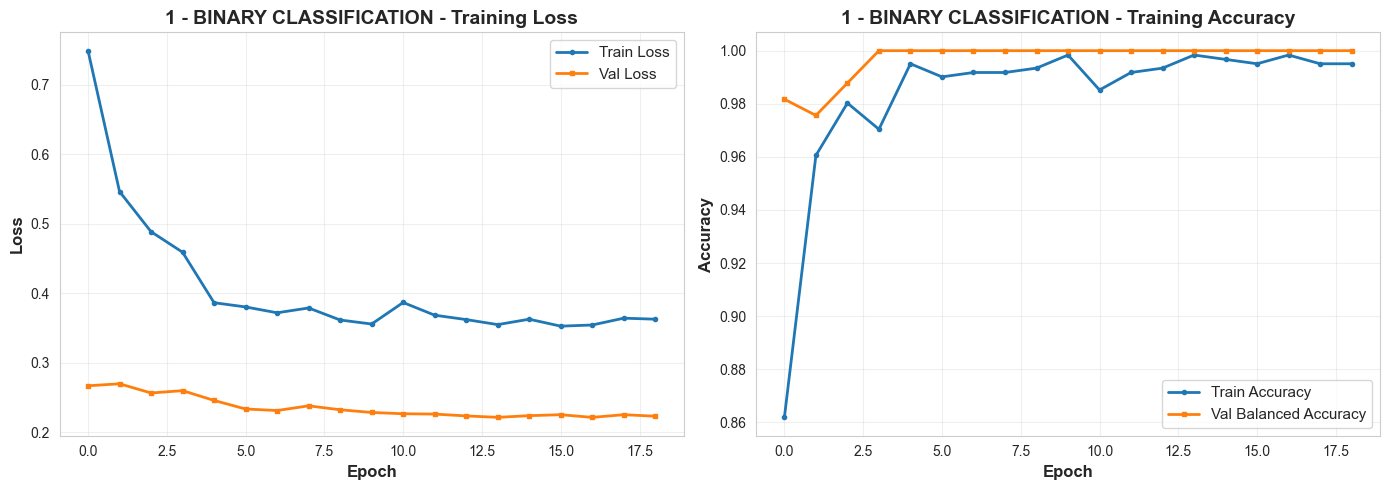


🎯 Test Results:


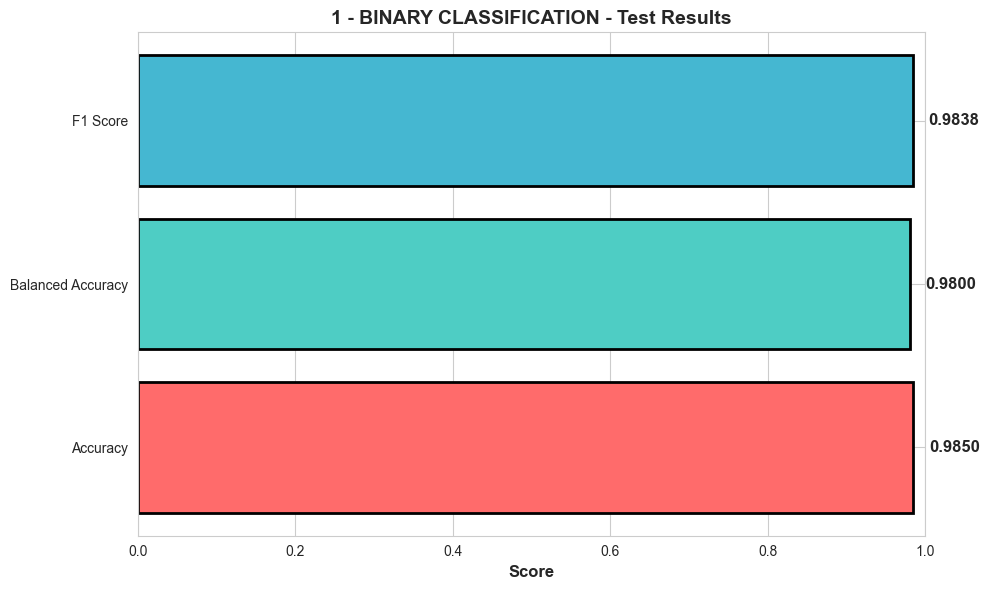


🗂️ Confusion Matrix:


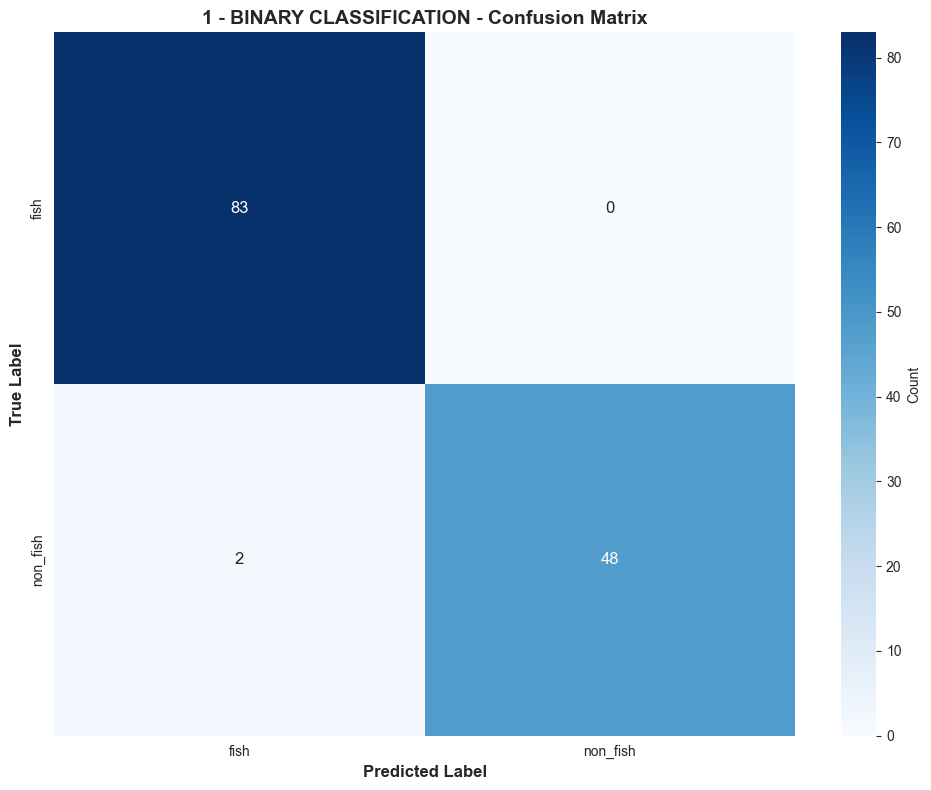


📋 Classification Report:
              precision    recall  f1-score   support

        fish     0.9765    1.0000    0.9881        83
    non_fish     1.0000    0.9600    0.9796        50

    accuracy                         0.9850       133
   macro avg     0.9882    0.9800    0.9838       133
weighted avg     0.9853    0.9850    0.9849       133


🔄 ONNX Conversion:

🔄 Converting model to ONNX: C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv\train\Effecient_best1_binary_model.onnx


ModuleNotFoundError: No module named 'onnxscript'

In [11]:
# Train Stage 1
stage1_model, stage1_label_map, stage1_idx_map = train_stage(
    csv_path=STAGE1_TRAIN_CSV,
    label_column="binary_label",
    model_save_path=STAGE1_MODEL_PATH,
    onnx_save_path=STAGE1_ONNX_PATH,
    stage_name="1 - BINARY CLASSIFICATION"
)

## 1️⃣1️⃣ STAGE 2: Species Classification


🚀 TRAINING STAGE 2 - SPECIES CLASSIFICATION

📊 Data Distribution:


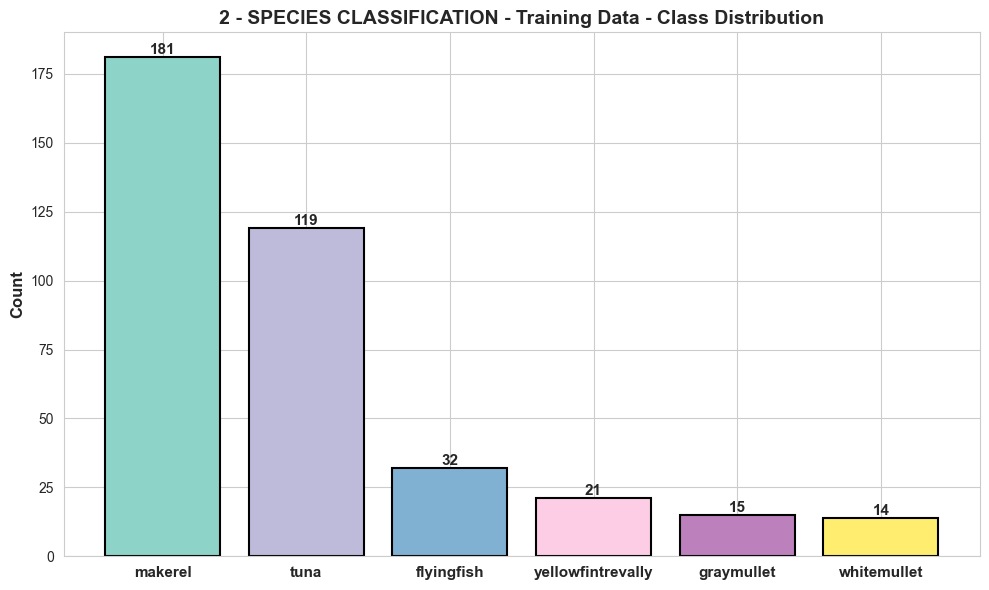


📈 Dataset Info:
  Train samples: 382
  Val samples: 82
  Test samples: 83
  Classes: ['flyingfish', 'graymullet', 'makerel', 'tuna', 'whitemullet', 'yellowfintrevally']



⏳ Starting training...
Epoch 01/50 | Loss: 2.0119/1.4029 | Acc: 0.5408/0.7244

🔓 Backbone unfrozen at epoch 4
Epoch 05/50 | Loss: 0.7758/0.9869 | Acc: 0.9185/0.9957
Epoch 10/50 | Loss: 0.7077/0.9227 | Acc: 0.9511/1.0000
Epoch 15/50 | Loss: 0.7124/0.9092 | Acc: 0.9538/1.0000
Epoch 20/50 | Loss: 0.6521/0.9002 | Acc: 0.9783/1.0000

⏹️ Early stopping at epoch 22

✨ Best model from epoch 7 (Bal Acc: 1.0000)

📉 Training History:


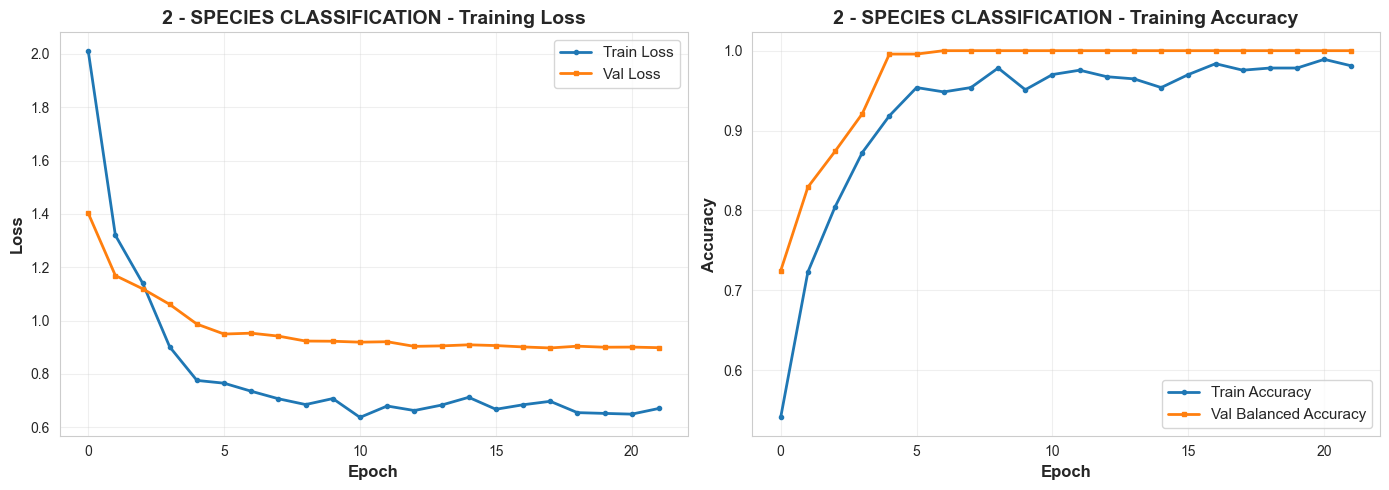


🎯 Test Results:


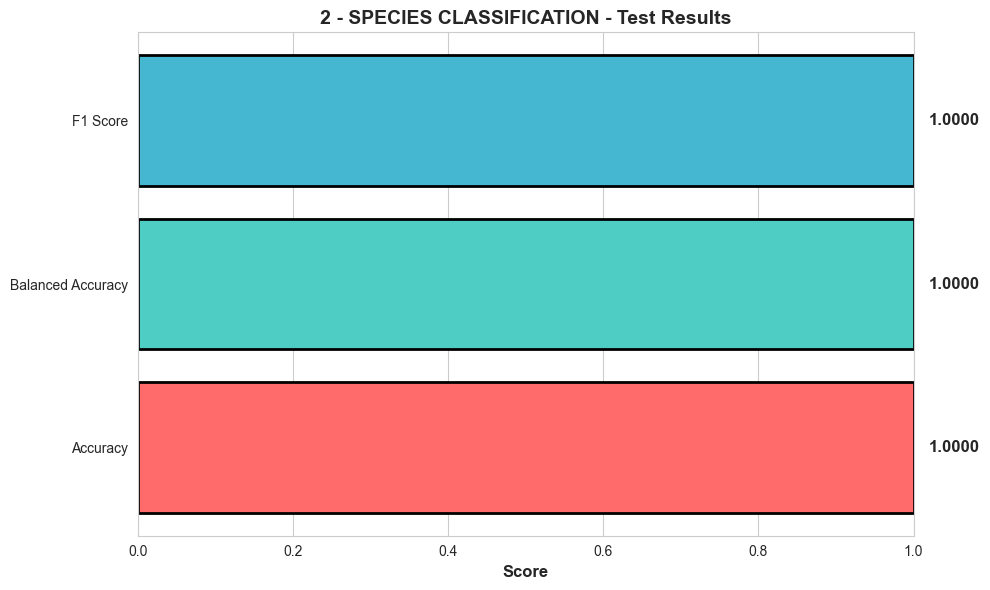


🗂️ Confusion Matrix:


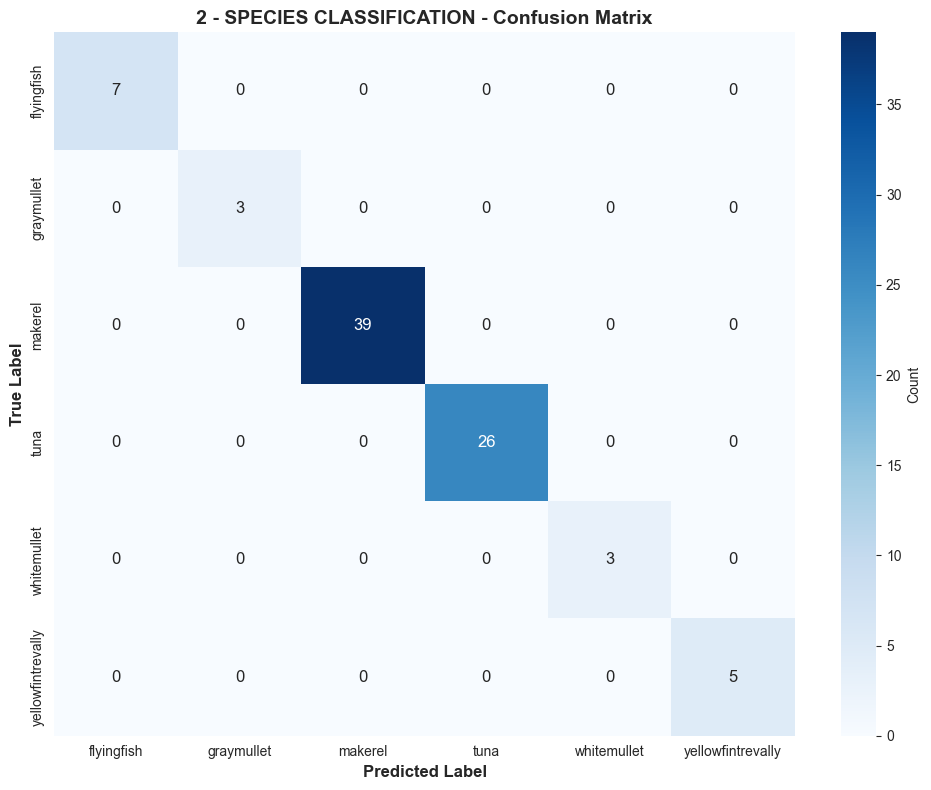


📋 Classification Report:
                   precision    recall  f1-score   support

       flyingfish     1.0000    1.0000    1.0000         7
       graymullet     1.0000    1.0000    1.0000         3
          makerel     1.0000    1.0000    1.0000        39
             tuna     1.0000    1.0000    1.0000        26
      whitemullet     1.0000    1.0000    1.0000         3
yellowfintrevally     1.0000    1.0000    1.0000         5

         accuracy                         1.0000        83
        macro avg     1.0000    1.0000    1.0000        83
     weighted avg     1.0000    1.0000    1.0000        83


🔄 ONNX Conversion:

🔄 Converting model to ONNX: C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv\train\Effecient_best1_species_model.onnx


ModuleNotFoundError: No module named 'onnxscript'

In [12]:
# Train Stage 2
stage2_model, stage2_label_map, stage2_idx_map = train_stage(
    csv_path=STAGE2_TRAIN_CSV,
    label_column="species_label",
    model_save_path=STAGE2_MODEL_PATH,
    onnx_save_path=STAGE2_ONNX_PATH,
    stage_name="2 - SPECIES CLASSIFICATION"
)

## 1️⃣2️⃣ STAGE 3: Grade Classification (A, B, C)


🚀 TRAINING STAGE 3 - GRADE CLASSIFICATION

📊 Data Distribution:


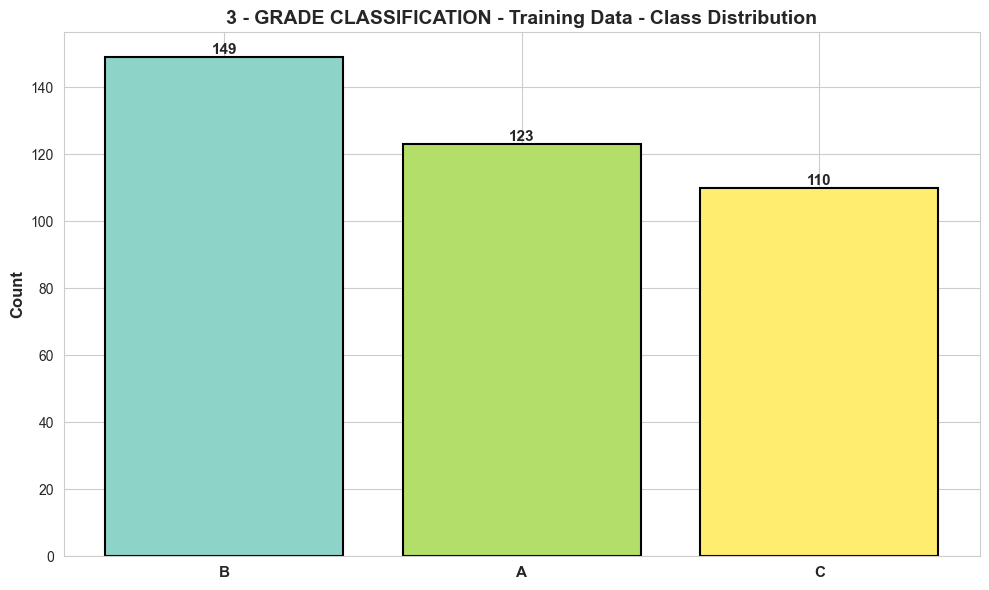


📈 Dataset Info:
  Train samples: 382
  Val samples: 82
  Test samples: 83
  Classes: ['A', 'B', 'C']

⏳ Starting training...
Epoch 01/50 | Loss: 1.7118/0.7440 | Acc: 0.5326/0.7714

🔓 Backbone unfrozen at epoch 4
Epoch 05/50 | Loss: 0.9924/0.4447 | Acc: 0.8859/0.9107
Epoch 10/50 | Loss: 0.7178/0.4314 | Acc: 0.9647/0.9170
Epoch 15/50 | Loss: 0.6188/0.4332 | Acc: 0.9701/0.9583
Epoch 20/50 | Loss: 0.5912/0.3930 | Acc: 0.9837/0.9583
Epoch 25/50 | Loss: 0.5797/0.4028 | Acc: 0.9891/0.9564
Epoch 30/50 | Loss: 0.5665/0.4057 | Acc: 0.9973/0.9564

⏹️ Early stopping at epoch 31

✨ Best model from epoch 16 (Bal Acc: 0.9688)

📉 Training History:


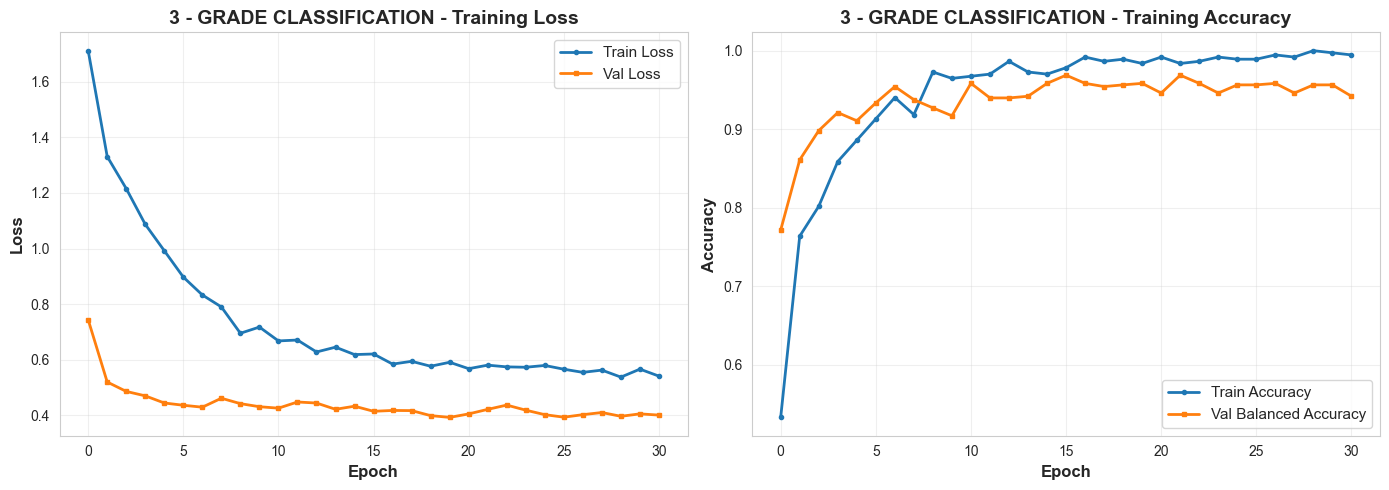


🎯 Test Results:


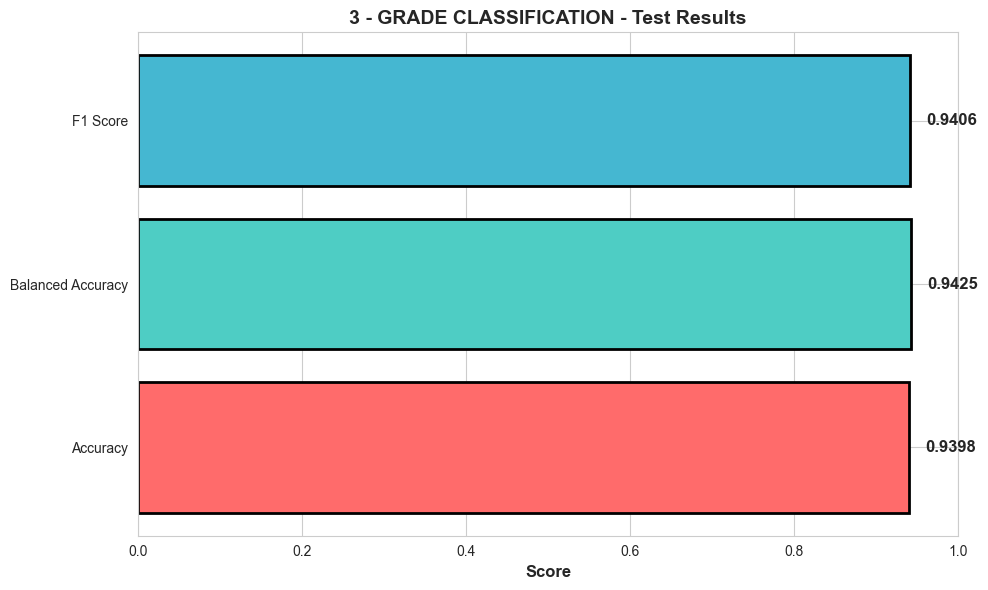


🗂️ Confusion Matrix:


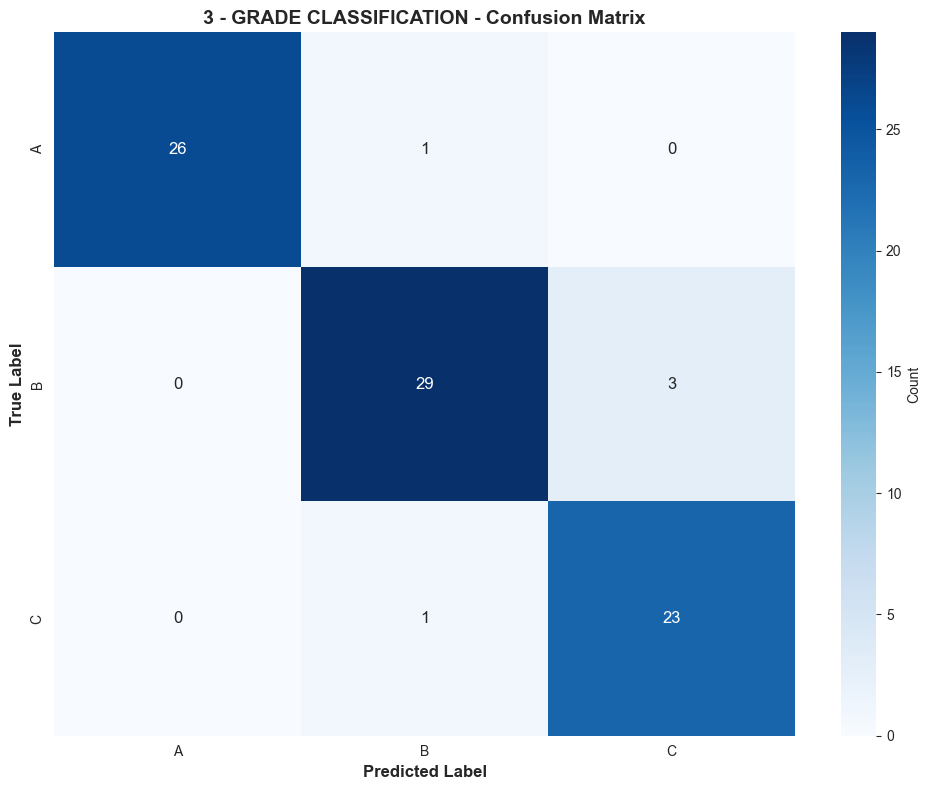


📋 Classification Report:
              precision    recall  f1-score   support

           A     1.0000    0.9630    0.9811        27
           B     0.9355    0.9062    0.9206        32
           C     0.8846    0.9583    0.9200        24

    accuracy                         0.9398        83
   macro avg     0.9400    0.9425    0.9406        83
weighted avg     0.9418    0.9398    0.9401        83


🔄 ONNX Conversion:

🔄 Converting model to ONNX: C:\Users\User\Desktop\Research Final Year\Test RP\model\fish_quality_grade\data_csv\train\Effecient_best1_grade_model.onnx


ModuleNotFoundError: No module named 'onnxscript'

In [13]:
# Train Stage 3
stage3_model, stage3_label_map, stage3_idx_map = train_stage(
    csv_path=STAGE3_TRAIN_CSV,
    label_column="grade_label",
    model_save_path=STAGE3_MODEL_PATH,
    onnx_save_path=STAGE3_ONNX_PATH,
    stage_name="3 - GRADE CLASSIFICATION"
)

## 1️⃣3️⃣ Final Summary & Model Verification

In [15]:
# Save label mappings
mappings = {
    "stage1": {"label_to_idx": stage1_label_map, "idx_to_label": stage1_idx_map},
    "stage2": {"label_to_idx": stage2_label_map, "idx_to_label": stage2_idx_map},
    "stage3": {"label_to_idx": stage3_label_map, "idx_to_label": stage3_idx_map},
}
torch.save(mappings, os.path.join(train_dir, "label_mappings.pth"))

print("\n" + "="*80)
print("✅ TRAINING PIPELINE COMPLETE!")
print("="*80)

# Summary table
print(f"\n📊 GENERATED FILES:")
print("-" * 80)

files_to_check = [
    (STAGE1_MODEL_PATH, "Stage 1 PyTorch Model"),
    (STAGE1_ONNX_PATH, "Stage 1 ONNX Model"),
    (STAGE2_MODEL_PATH, "Stage 2 PyTorch Model"),
    (STAGE2_ONNX_PATH, "Stage 2 ONNX Model"),
    (STAGE3_MODEL_PATH, "Stage 3 PyTorch Model"),
    (STAGE3_ONNX_PATH, "Stage 3 ONNX Model"),
    (os.path.join(train_dir, "label_mappings.pth"), "Label Mappings"),
]

for file_path, description in files_to_check:
    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"✅ {description:.<40} {size_mb:>8.2f} MB")
    else:
        print(f"❌ {description:.<40} NOT FOUND")

print("-" * 80)
print("\n🚀 Next Steps:")
print("1. Copy ONNX files to: mobile/assets/models/")
print("2. Rename files to: fish_detector_1.onnx, species_classifier_1.onnx, grade_classifier_1.onnx")
print("3. Update modelPaths.ts with new model paths")
print("4. Run mobile app with: pnpm expo start")
print("\n" + "="*80)

NameError: name 'stage1_label_map' is not defined